In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("../../data/loan_default/accepted_2007_to_2018q4.csv", low_memory=False)

print("Shape            :", df.shape)
print("Total loans      :", len(df))
print("Total columns    :", df.shape[1])

Shape            : (2260701, 151)
Total loans      : 2260701
Total columns    : 151


In [2]:
# Understand the Target Variable
print("LOAN STATUS DISTRIBUTION")
print()
print(df["loan_status"].value_counts())
print()

default_statuses = ["Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)", "Does not meet the credit policy. Status:Charged Off"]
df["is_default"] = df["loan_status"].isin(default_statuses).astype(int)

total = len(df)
defaults = df["is_default"].sum()
print(f"Total loans      : {total:,}")
print(f"Defaults         : {defaults:,} ({round(defaults/total*100, 2)}%)")
print(f"Non-defaults     : {total-defaults:,} ({round((total-defaults)/total*100, 2)}%)")
print(f"Imbalance ratio  : {round((total-defaults)/defaults, 1)}:1")

LOAN STATUS DISTRIBUTION

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Total loans      : 2,260,701
Defaults         : 295,176 (13.06%)
Non-defaults     : 1,965,525 (86.94%)
Imbalance ratio  : 6.7:1


In [3]:
# Select and Clean Key Features
key_features = [
    "loan_amnt", "funded_amnt", "int_rate", "installment",
    "annual_inc", "dti", "delinq_2yrs", "fico_range_low",
    "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
    "emp_length", "home_ownership", "purpose", "grade",
    "loan_status", "is_default"
]

df = df[key_features].copy()

print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(missing_df)
print()

df["emp_length"] = df["emp_length"].str.replace(" years", "").str.replace(" year", "").str.replace("+", "").str.replace("< 1", "0")
df["emp_length"] = pd.to_numeric(df["emp_length"], errors="coerce")
df["revol_util"] = pd.to_numeric(df["revol_util"], errors="coerce")

df = df.dropna(subset=["annual_inc", "dti", "revol_util", "fico_range_low"])

print(f"Shape after cleaning: {df.shape}")
print(f"Defaults remaining  : {df['is_default'].sum():,}")

Missing values per column:
                      missing_count  missing_pct
emp_length                   146940       6.5000
mort_acc                      50063       2.2100
dti                            1744       0.0800
revol_util                     1835       0.0800
pub_rec_bankruptcies           1398       0.0600
loan_amnt                        33       0.0000
revol_bal                        33       0.0000
grade                            33       0.0000
purpose                          33       0.0000
home_ownership                   33       0.0000
total_acc                        62       0.0000
pub_rec                          62       0.0000
funded_amnt                      33       0.0000
open_acc                         62       0.0000
fico_range_high                  33       0.0000
fico_range_low                   33       0.0000
delinq_2yrs                      62       0.0000
annual_inc                       37       0.0000
installment                      33       

KEY FEATURE ANALYSIS

loan_amnt            Default mean:     15677.46  |  Non-default mean:     14950.92  |  Diff: 4.9%
int_rate             Default mean:        15.70  |  Non-default mean:        12.70  |  Diff: 23.6%
annual_inc           Default mean:     71033.00  |  Non-default mean:     79095.54  |  Diff: 10.2%
dti                  Default mean:        20.15  |  Non-default mean:        18.63  |  Diff: 8.2%
fico_range_low       Default mean:       688.23  |  Non-default mean:       700.13  |  Diff: 1.7%
revol_util           Default mean:        54.31  |  Non-default mean:        49.74  |  Diff: 9.2%
installment          Default mean:       468.00  |  Non-default mean:       442.44  |  Diff: 5.8%


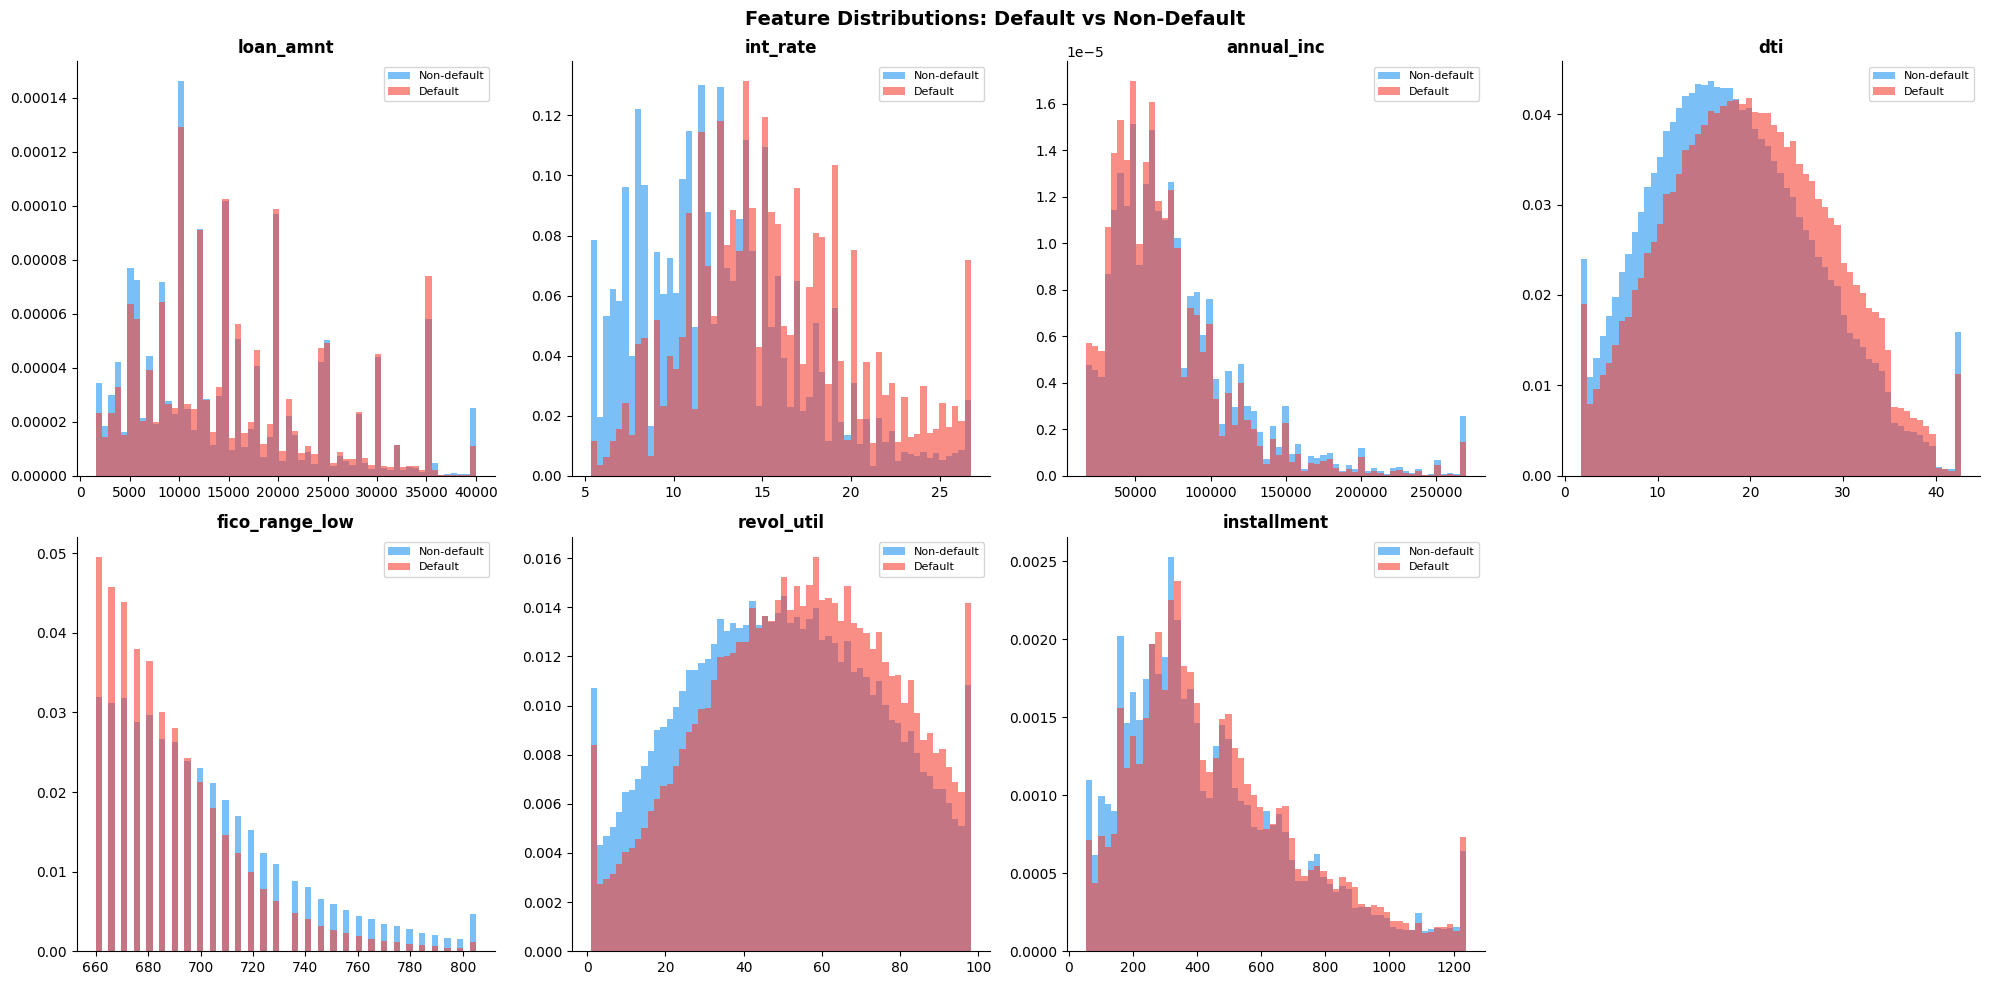

In [5]:
# Key Feature Analysis
print("KEY FEATURE ANALYSIS")
print()

numeric_features = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_low", "revol_util", "installment"]

for feat in numeric_features:
    default_mean = df[df["is_default"] == 1][feat].mean()
    legit_mean = df[df["is_default"] == 0][feat].mean()
    diff_pct = abs(default_mean - legit_mean) / legit_mean * 100
    print(f"{feat:<20} Default mean: {default_mean:>12.2f}  |  Non-default mean: {legit_mean:>12.2f}  |  Diff: {diff_pct:.1f}%")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    default_vals = df[df["is_default"] == 1][feat].dropna()
    legit_vals = df[df["is_default"] == 0][feat].dropna()
    clip_min = df[feat].quantile(0.01)
    clip_max = df[feat].quantile(0.99)
    axes[i].hist(legit_vals.clip(clip_min, clip_max), bins=60, color="#2196F3", alpha=0.6, label="Non-default", density=True)
    axes[i].hist(default_vals.clip(clip_min, clip_max), bins=60, color="#F44336", alpha=0.6, label="Default", density=True)
    axes[i].set_title(feat, fontweight="bold")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Feature Distributions: Default vs Non-Default", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/loan_default/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

LOAN GRADE DEFAULT RATE ANALYSIS

        total  defaults  default_rate_%
grade                                  
A      432543     15870          3.6690
B      662668     58406          8.8138
C      648977     94733         14.5973
D      323723     66902         20.6664
E      135398     38724         28.6001
F       41719     15331         36.7482
G       12131      4894         40.3429

LOAN PURPOSE DEFAULT RATE ANALYSIS
                      count  default_rate_%
purpose                                    
educational             421         20.9026
small_business        24643         20.5170
renewable_energy       1443         16.6320
moving                15339         15.9332
debt_consolidation  1276135         14.1169
medical               27403         13.6737
other                138994         13.2236
house                 14094         12.9417
vacation              15485         12.4378
wedding                2353         12.4097


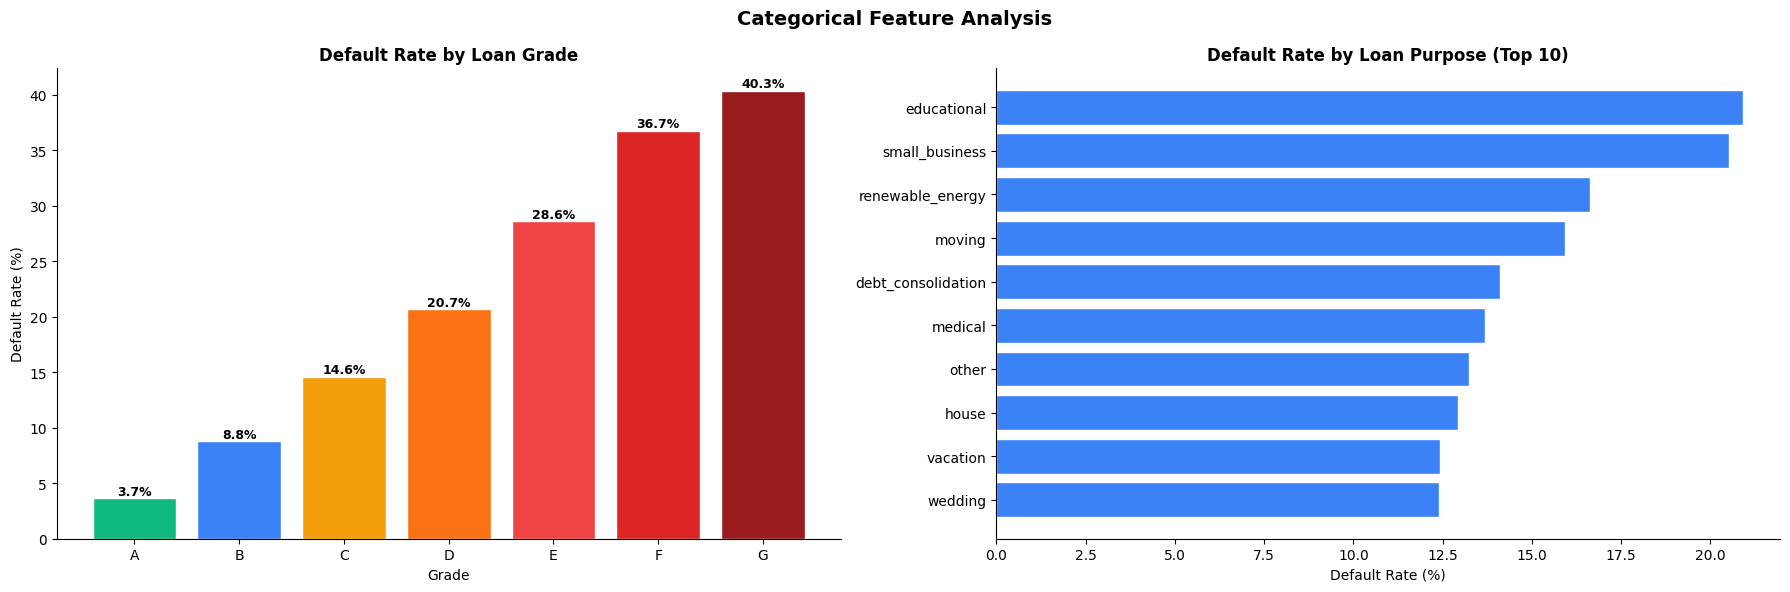

In [6]:
# Grade and Purpose Analysis
print("LOAN GRADE DEFAULT RATE ANALYSIS")
print()

grade_analysis = df.groupby("grade")["is_default"].agg(["mean", "count", "sum"])
grade_analysis["default_rate_%"] = grade_analysis["mean"] * 100
grade_analysis = grade_analysis.drop(columns="mean").rename(columns={"count": "total", "sum": "defaults"})
print(grade_analysis.sort_index())

print()
print("LOAN PURPOSE DEFAULT RATE ANALYSIS")
purpose_analysis = df.groupby("purpose")["is_default"].agg(["mean", "count"])
purpose_analysis["default_rate_%"] = purpose_analysis["mean"] * 100
purpose_analysis = purpose_analysis.sort_values("default_rate_%", ascending=False)
print(purpose_analysis[["count", "default_rate_%"]].head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grade_rates = grade_analysis["default_rate_%"].sort_index()
colors = ["#10b981", "#3b82f6", "#f59e0b", "#f97316", "#ef4444", "#dc2626", "#991b1b"]
axes[0].bar(grade_rates.index, grade_rates.values, color=colors[:len(grade_rates)], edgecolor="white")
axes[0].set_title("Default Rate by Loan Grade", fontweight="bold")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Default Rate (%)")
for i, (g, v) in enumerate(grade_rates.items()):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

top_purposes = purpose_analysis.head(10)
axes[1].barh(top_purposes.index, top_purposes["default_rate_%"], color="#3b82f6", edgecolor="white")
axes[1].set_title("Default Rate by Loan Purpose (Top 10)", fontweight="bold")
axes[1].set_xlabel("Default Rate (%)")
axes[1].invert_yaxis()

plt.suptitle("Categorical Feature Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/loan_default/categorical_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

FICO SCORE AND INTEREST RATE ANALYSIS

Default rate by FICO score bucket:
               count  default_rate_%
fico_bucket                         
(580, 620]         4         25.0000
(620, 660]    186821         18.9047
(660, 700]   1240412         15.3769
(700, 740]    589895          9.4266
(740, 780]    179307          5.9652
(780, 820]     55234          4.1732
(820, 860]      5486          3.5727

Default rate by interest rate bucket:
             count  default_rate_%
int_bucket                        
(5, 8]      381785          3.5811
(8, 11]     456629          7.7840
(11, 14]    586219         12.7962
(14, 17]    408652         16.4502
(17, 20]    246519         22.4348
(20, 24]    108291         25.5728
(24, 30]     60265         29.3105


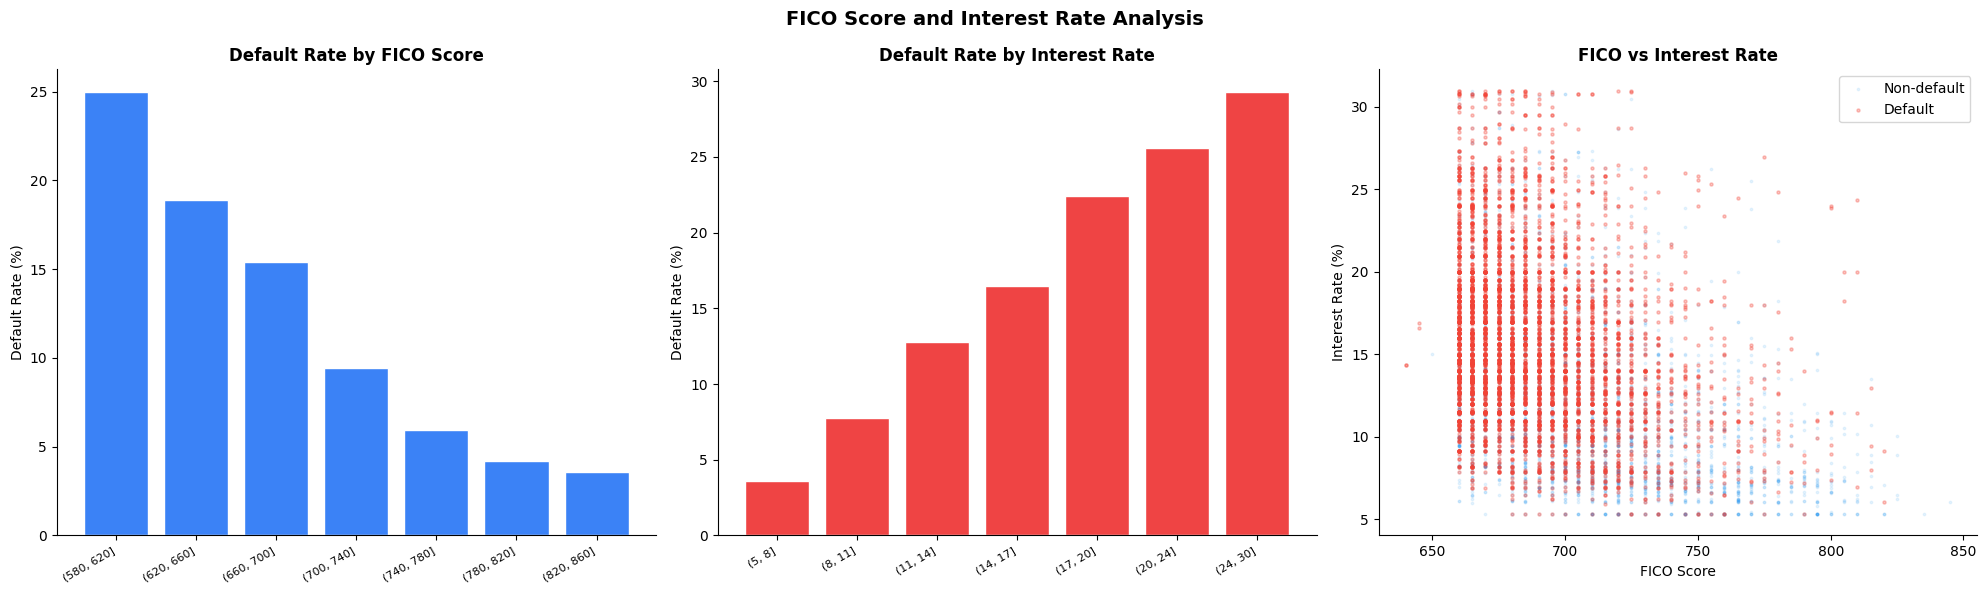

In [7]:
#  FICO Score and Interest Rate Deep Analysis
print("FICO SCORE AND INTEREST RATE ANALYSIS")
print()

fico_bins = [580, 620, 660, 700, 740, 780, 820, 860]
df["fico_bucket"] = pd.cut(df["fico_range_low"], bins=fico_bins)

fico_default = df.groupby("fico_bucket", observed=True)["is_default"].agg(["mean", "count"])
fico_default["default_rate_%"] = fico_default["mean"] * 100
print("Default rate by FICO score bucket:")
print(fico_default[["count", "default_rate_%"]])

print()
int_bins = [5, 8, 11, 14, 17, 20, 24, 30]
df["int_bucket"] = pd.cut(df["int_rate"], bins=int_bins)
int_default = df.groupby("int_bucket", observed=True)["is_default"].agg(["mean", "count"])
int_default["default_rate_%"] = int_default["mean"] * 100
print("Default rate by interest rate bucket:")
print(int_default[["count", "default_rate_%"]])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fico_rates = fico_default["default_rate_%"]
axes[0].bar(range(len(fico_rates)), fico_rates.values, color="#3b82f6", edgecolor="white")
axes[0].set_xticks(range(len(fico_rates)))
axes[0].set_xticklabels([str(b) for b in fico_rates.index], rotation=30, ha="right", fontsize=8)
axes[0].set_title("Default Rate by FICO Score", fontweight="bold")
axes[0].set_ylabel("Default Rate (%)")

int_rates = int_default["default_rate_%"]
axes[1].bar(range(len(int_rates)), int_rates.values, color="#ef4444", edgecolor="white")
axes[1].set_xticks(range(len(int_rates)))
axes[1].set_xticklabels([str(b) for b in int_rates.index], rotation=30, ha="right", fontsize=8)
axes[1].set_title("Default Rate by Interest Rate", fontweight="bold")
axes[1].set_ylabel("Default Rate (%)")

axes[2].scatter(
    df[df["is_default"] == 0]["fico_range_low"].sample(5000, random_state=42),
    df[df["is_default"] == 0]["int_rate"].sample(5000, random_state=42),
    alpha=0.1, color="#2196F3", s=3, label="Non-default"
)
axes[2].scatter(
    df[df["is_default"] == 1]["fico_range_low"].sample(min(5000, df["is_default"].sum()), random_state=42),
    df[df["is_default"] == 1]["int_rate"].sample(min(5000, df["is_default"].sum()), random_state=42),
    alpha=0.3, color="#F44336", s=5, label="Default"
)
axes[2].set_title("FICO vs Interest Rate", fontweight="bold")
axes[2].set_xlabel("FICO Score")
axes[2].set_ylabel("Interest Rate (%)")
axes[2].legend()

plt.suptitle("FICO Score and Interest Rate Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/loan_default/fico_interest_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Key Findings
print("KEY FINDINGS — LOAN DEFAULT")
print()

default_rate = df["is_default"].mean() * 100
print(f"1. Overall default rate        : {default_rate:.2f}%")
print()

grade_g = df[df["grade"] == "G"]["is_default"].mean() * 100
grade_a = df[df["grade"] == "A"]["is_default"].mean() * 100
print(f"2. Grade A default rate        : {grade_a:.2f}%")
print(f"   Grade G default rate        : {grade_g:.2f}%")
print(f"   Grade predicts risk strongly")
print()

high_int = df[df["int_rate"] > 20]["is_default"].mean() * 100
low_int = df[df["int_rate"] < 8]["is_default"].mean() * 100
print(f"3. Low interest (<8%) default  : {low_int:.2f}%")
print(f"   High interest (>20%) default: {high_int:.2f}%")
print()

high_fico = df[df["fico_range_low"] > 740]["is_default"].mean() * 100
low_fico = df[df["fico_range_low"] < 620]["is_default"].mean() * 100
print(f"4. High FICO (>740) default    : {high_fico:.2f}%")
print(f"   Low FICO (<620) default     : {low_fico:.2f}%")
print()

print(f"5. Dataset size after cleaning : {len(df):,} loans")
print(f"   Features selected           : {len(key_features) - 2}")
print()
print("Key signals for model:")
print("   int_rate, grade, fico_range_low, dti, annual_inc are strongest predictors")
print("   Will engineer risk score features combining these in notebook 2")

df.drop(columns=["fico_bucket", "int_bucket", "loan_status"], errors="ignore").to_csv(
    "../../data/loan_default/loan_cleaned.csv", index=False)
print()
print("Cleaned data saved to data/loan_default/loan_cleaned.csv")

KEY FINDINGS — LOAN DEFAULT

1. Overall default rate        : 13.06%

2. Grade A default rate        : 3.67%
   Grade G default rate        : 40.34%
   Grade predicts risk strongly

3. Low interest (<8%) default  : 3.58%
   High interest (>20%) default: 27.12%

4. High FICO (>740) default    : 5.50%
   Low FICO (<620) default     : 33.33%

5. Dataset size after cleaning : 2,257,159 loans
   Features selected           : 20

Key signals for model:
   int_rate, grade, fico_range_low, dti, annual_inc are strongest predictors
   Will engineer risk score features combining these in notebook 2

Cleaned data saved to data/loan_default/loan_cleaned.csv
